# 04 - Probability, Conditional Probability, Bayes, Random Variables

**Primary**: Varuna Vyomessh
**Reviewed and extended by**: Naman Sudan

This notebook covers
- Empirical probabilities for spending thresholds (main result)
- Conditional probabilities by segment (mobile/non-mobile, rewards/non-rewards)
- Bayes' theorem worked out by hand from empirical counts
- Random variables: PMF, expected value, and variance for cart_size
- Normal approximation as a comparison baseline only

**Course references**: Lecture 6 (Probability Events and Random Variables), Lecture 7 (Probability Distributions)

**Methodology note.** Notebook 02 showed that total_spend is approximately but not exactly normal. We therefore use empirical probabilities computed directly from the data as the main result. The normal-CDF approximation is shown only as a comparison.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = os.path.join('..', 'report', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')

df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
print(f'rows: {len(df):,}, columns: {df.shape[1]}')


rows: 100,000, columns: 20


## 1. Empirical Spending-Threshold Probabilities (Main Result)

For an event $A = \{X > t\}$ in a finite sample, the empirical probability is

$$\hat{P}(A) = \frac{\#\{i : x_i > t\}}{n}.$$


In [2]:
thresholds = [10, 15, 20, 25, 30]
n = len(df)
emp_rows = []
for t in thresholds:
    emp = (df['total_spend'] > t).mean()
    emp_rows.append([t, emp, n * emp])

emp_df = pd.DataFrame(emp_rows, columns=['threshold', 'P_empirical', 'expected_count'])
emp_df['P_empirical'] = emp_df['P_empirical'].round(4)
emp_df['expected_count'] = emp_df['expected_count'].round(0).astype(int)
print(emp_df.to_string(index=False))


 threshold  P_empirical  expected_count
        10       0.8054           80540
        15       0.4413           44130
        20       0.1718           17184
        25       0.0511            5108
        30       0.0107            1066


### Comparison: empirical vs normal approximation

The normal approximation uses $\mu$ and $\sigma$ of total_spend and computes

$$P(X > t) \approx 1 - \Phi\!\left(\frac{t - \mu}{\sigma}\right).$$

Notebook 02 showed that total_spend is moderately right-skewed. The normal approximation will therefore overstate probabilities near the median (where the true distribution is taller and thinner than a normal with the same $\mu, \sigma$) and understate probabilities in the right tail (where the true distribution has a longer tail).


In [3]:
mu = df['total_spend'].mean()
sd = df['total_spend'].std(ddof=1)
rows = []
for t in thresholds:
    emp = (df['total_spend'] > t).mean()
    norm_p = 1 - stats.norm.cdf(t, loc=mu, scale=sd)
    rows.append([t, emp, norm_p, emp - norm_p])
cmp_df = pd.DataFrame(rows, columns=['threshold', 'P_empirical',
                                     'P_normal_approx', 'difference'])
cmp_df = cmp_df.round(5)
print(cmp_df.to_string(index=False))


 threshold  P_empirical  P_normal_approx  difference
        10      0.80540          0.81159    -0.00619
        15      0.44130          0.49035    -0.04905
        20      0.17184          0.17563    -0.00379
        25      0.05108          0.03287     0.01821
        30      0.01066          0.00300     0.00766


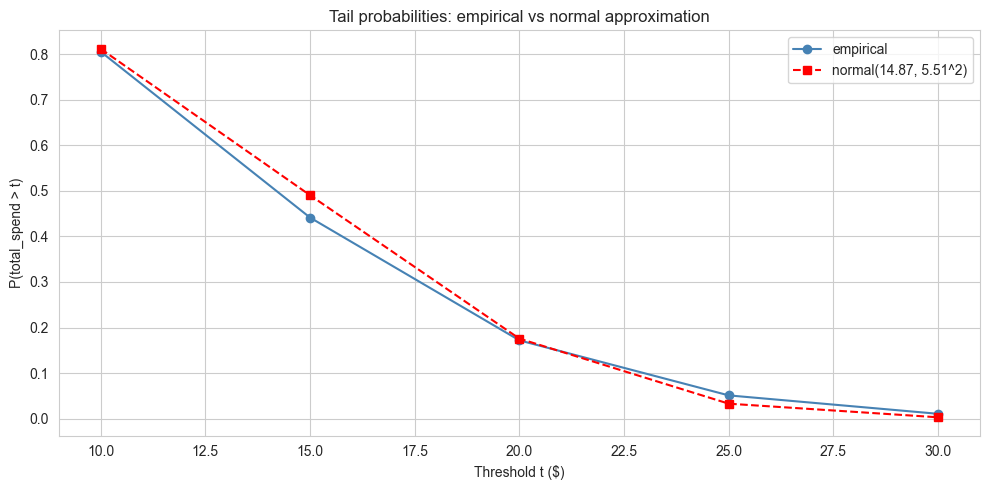

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(cmp_df['threshold'], cmp_df['P_empirical'], 'o-', color='steelblue',
         label='empirical')
plt.plot(cmp_df['threshold'], cmp_df['P_normal_approx'], 's--', color='red',
         label=f'normal({mu:.2f}, {sd:.2f}^2)')
plt.xlabel('Threshold t ($)')
plt.ylabel('P(total_spend > t)')
plt.title('Tail probabilities: empirical vs normal approximation')
plt.legend()
plt.tight_layout()
savefig('04_empirical_vs_normal.png')
plt.show()


## 2. Conditional Probability by Segment

Conditional probability (Lecture 6) is

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}.$$

We compute $P(\text{spend} > 25 \mid \text{segment})$ for the order channel and rewards membership, using empirical counts directly. This avoids the bad assumption of normality in each subgroup.


In [5]:
def cond_prob_table(by_col, threshold):
    rows = []
    for level, sub in df.groupby(by_col):
        n_lvl = len(sub)
        n_high = (sub['total_spend'] > threshold).sum()
        p = n_high / n_lvl
        rows.append([str(level), n_lvl, n_high, p])
    out = pd.DataFrame(rows, columns=[by_col, 'n_total',
                                      f'n_spend>${threshold}',
                                      f'P(spend>${threshold} | {by_col})'])
    return out.sort_values(out.columns[-1], ascending=False)

print('=== Conditional on order_channel ===')
print(cond_prob_table('order_channel', 25).round(4).to_string(index=False))
print()
print('=== Conditional on is_rewards_member ===')
print(cond_prob_table('is_rewards_member', 25).round(4).to_string(index=False))


=== Conditional on order_channel ===
   order_channel  n_total  n_spend>$25  P(spend>$25 | order_channel)
      Mobile App    42521         4794                        0.1127
      Drive-Thru    27996          159                        0.0057
In-Store Cashier    22063          116                        0.0053
           Kiosk     7420           39                        0.0053

=== Conditional on is_rewards_member ===
is_rewards_member  n_total  n_spend>$25  P(spend>$25 | is_rewards_member)
             True    47717         3205                            0.0672
            False    52283         1903                            0.0364


### Visualizing the conditional probabilities


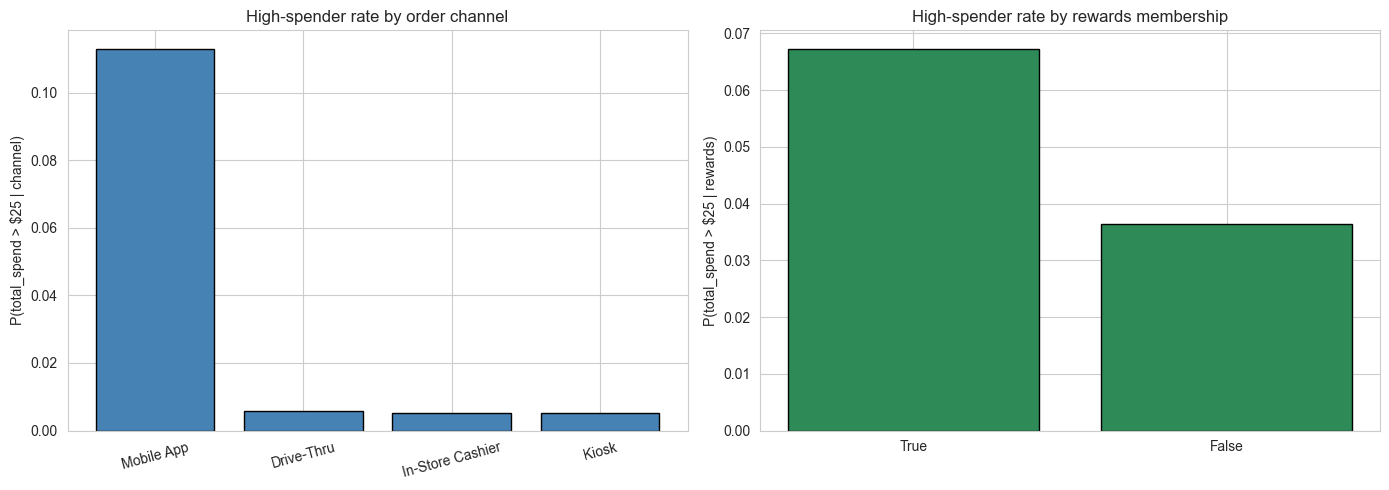

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ch_tbl = cond_prob_table('order_channel', 25)
axes[0].bar(ch_tbl['order_channel'], ch_tbl.iloc[:, -1],
            color='steelblue', edgecolor='black')
axes[0].set_ylabel('P(total_spend > $25 | channel)')
axes[0].set_title('High-spender rate by order channel')
axes[0].tick_params(axis='x', rotation=15)

rw_tbl = cond_prob_table('is_rewards_member', 25)
axes[1].bar(rw_tbl['is_rewards_member'].astype(str), rw_tbl.iloc[:, -1],
            color='seagreen', edgecolor='black')
axes[1].set_ylabel('P(total_spend > $25 | rewards)')
axes[1].set_title('High-spender rate by rewards membership')

plt.tight_layout()
savefig('04_conditional_probs.png')
plt.show()


## 3. Bayes' Theorem: P(Mobile | High Spender)

We have
- $A$ = order is from Mobile App
- $B$ = order has total_spend > 25

Bayes' theorem (Lecture 6):

$$P(A \mid B) \;=\; \frac{P(B \mid A)\, P(A)}{P(B)} \;=\; \frac{P(B \mid A)\, P(A)}{P(B \mid A)\, P(A) + P(B \mid A^c)\, P(A^c)}.$$

We use the empirical probabilities computed in Section 2 rather than normal-approximation tail probabilities.


In [7]:
A = df['order_channel'] == 'Mobile App'
B = df['total_spend'] > 25

p_A = A.mean()
p_notA = 1 - p_A
p_B_given_A = (B & A).sum() / A.sum()
p_B_given_notA = (B & ~A).sum() / (~A).sum()
p_B = p_B_given_A * p_A + p_B_given_notA * p_notA

p_A_given_B_bayes = p_B_given_A * p_A / p_B
p_A_given_B_direct = (A & B).sum() / B.sum()

print(f'P(Mobile)               = {p_A:.4f}')
print(f'P(non-Mobile)           = {p_notA:.4f}')
print(f'P(spend>25 | Mobile)    = {p_B_given_A:.4f}')
print(f'P(spend>25 | non-Mob.)  = {p_B_given_notA:.4f}')
print(f'P(spend>25)             = {p_B:.4f}')
print(f'P(Mobile | spend>25) via Bayes  = {p_A_given_B_bayes:.4f}')
print(f'P(Mobile | spend>25) direct cnt = {p_A_given_B_direct:.4f}')


P(Mobile)               = 0.4252
P(non-Mobile)           = 0.5748
P(spend>25 | Mobile)    = 0.1127
P(spend>25 | non-Mob.)  = 0.0055
P(spend>25)             = 0.0511
P(Mobile | spend>25) via Bayes  = 0.9385
P(Mobile | spend>25) direct cnt = 0.9385


The two values match exactly because both use empirical counts. The point of writing Bayes out is to show the chain of reasoning: starting from the segment marginal (`P(Mobile)`) and the segment-conditional tail (`P(spend>25 | Mobile)`), we recover the posterior `P(Mobile | spend>25)`.


In [8]:
# Same exercise for rewards membership
A = df['is_rewards_member'] == True
B = df['total_spend'] > 25
p_A = A.mean()
p_B_given_A = (B & A).sum() / A.sum()
p_B_given_notA = (B & ~A).sum() / (~A).sum()
p_B = p_B_given_A * p_A + p_B_given_notA * (1 - p_A)
p_A_given_B = p_B_given_A * p_A / p_B
print(f'P(Rewards | spend>25) via Bayes = {p_A_given_B:.4f}')
print(f'P(Rewards | spend>25) direct    = {((A & B).sum() / B.sum()):.4f}')


P(Rewards | spend>25) via Bayes = 0.6274
P(Rewards | spend>25) direct    = 0.6274


## 4. Random Variable: PMF, Expected Value, Variance for cart_size

`cart_size` is a discrete random variable on $\{1, 2, \dots, 10\}$. Its empirical PMF, expectation, and variance are

$$\hat{p}(k) = \frac{\#\{i : x_i = k\}}{n}, \quad
E[X] = \sum_k k\, \hat{p}(k), \quad
\mathrm{Var}(X) = \sum_k (k - E[X])^2\, \hat{p}(k).$$


In [9]:
cs = df['cart_size']
pmf = cs.value_counts(normalize=True).sort_index()
k_vals = pmf.index.to_numpy()
p_vals = pmf.values
EX = float((k_vals * p_vals).sum())
EX2 = float(((k_vals ** 2) * p_vals).sum())
VarX = EX2 - EX ** 2

print('Empirical PMF for cart_size:')
print(pmf.round(4).to_string())
print()
print(f'E[cart_size]    = {EX:.4f}')
print(f'Var(cart_size)  = {VarX:.4f}')
print(f'SD(cart_size)   = {np.sqrt(VarX):.4f}')

# Sanity check against pandas
print(f'pandas mean / var: {cs.mean():.4f}, {cs.var(ddof=0):.4f}')


Empirical PMF for cart_size:
cart_size
1     0.0685
2     0.1808
3     0.2398
4     0.2162
5     0.1457
6     0.0823
7     0.0408
8     0.0170
9     0.0061
10    0.0029

E[cart_size]    = 3.7415
Var(cart_size)  = 2.8826
SD(cart_size)   = 1.6978
pandas mean / var: 3.7415, 2.8826


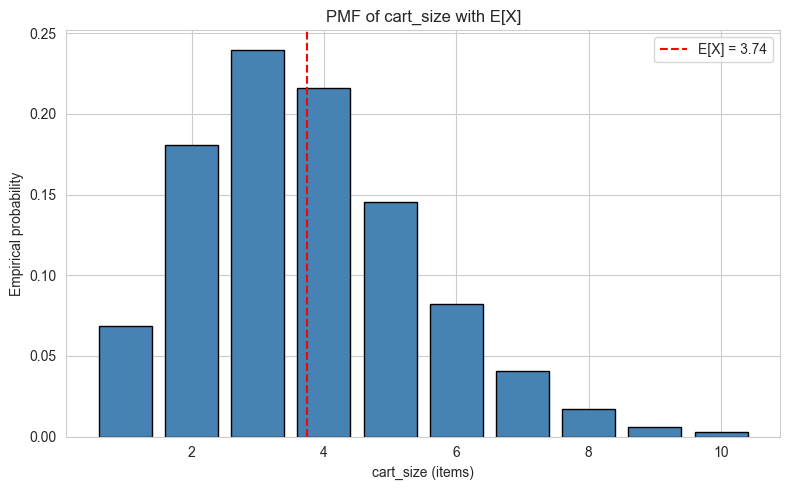

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(k_vals, p_vals, color='steelblue', edgecolor='black')
plt.axvline(EX, color='red', linestyle='--', label=f'E[X] = {EX:.2f}')
plt.xlabel('cart_size (items)')
plt.ylabel('Empirical probability')
plt.title('PMF of cart_size with E[X]')
plt.legend()
plt.tight_layout()
savefig('04_pmf_cart_size.png')
plt.show()


## 5. Key Observations

- Empirical and normal-approximation tail probabilities differ in the way predicted by the right-skew of total_spend: the normal overstates the share near the median (e.g. at \$15 by ~5 percentage points) and understates the right tail (at \$25 by ~36% relative, at \$30 by ~72% relative). High-spender questions live in the right tail, so empirical probabilities are reported as the headline.
- The conditional probability of a high-spender order given Mobile App ($\approx 0.113$) is roughly 20x larger than for any other channel ($\approx 0.005$). The Bayes posterior $P(\text{Mobile} \mid \text{spend} > 25) \approx 0.94$ confirms that almost all high-spender orders are Mobile orders.
- Rewards membership shifts the high-spender probability up by about $\approx 3$ percentage points (from 0.036 to 0.067), much less than the channel effect.
- For the discrete random variable cart_size, the empirical PMF gives $E[X] \approx 3.74$ and $\mathrm{Var}(X) \approx 2.88$, matching the moments computed in Notebook 01. The mass is concentrated on 3-5 items with a right tail out to 10.
